# Esercizio 2 - REINFORCE con baseline di valore

Il notebook studia come ridurre la varianza dell'aggiornamento REINFORCE su `CartPole-v1` sottraendo una baseline dal return Monte Carlo. Confronta return grezzi, return standardizzati per episodio e una baseline di valore appresa `V(s)`.

Le tre run condividono seed, architettura della policy, famiglia di ottimizzatori, numero di episodi e protocollo di valutazione; cambia soltanto la baseline.


> **Ambiente di esecuzione**
>
> Il laboratorio è stato eseguito in Ubuntu/WSL con il kernel `Python (DRL)`. Installare dalla root della repository con `python -m pip install -r requirements.txt`.
>
> Gli output della run completa sono preservati. Nella configurazione di consegna training e rendering sono disattivati; confronto, metriche e riepilogo dei cinque episodi vengono letti dagli artefatti versionati.


In [10]:
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

PROJECT_ROOT


PosixPath('./DLA_3')

In [ ]:
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dla_lab3 import (
    ReinforceConfig,
    make_env,
    observation_scale,
    reinforce,
    reinforce_with_value_baseline,
    run_cartpole_visual_episodes,
    set_seed,
)
from dla_lab3.paths import checkpoint_dir
from dla_lab3.policy_gradient import policy_from_env, value_from_env
from IPython.display import Image, display

# Le tre run da 1000 episodi sono disattivate nella modalita' rapida.
RUN_VALUE_BASELINE_TRAINING = False
LOAD_SAVED_RESULTS = True
DISPLAY_SAVED_RESULTS = True
USE_VERSIONED_METRICS = True


## Baseline per policy gradient

Una baseline indipendente dall'azione può essere sottratta al segnale del policy gradient senza introdurre bias nel valore atteso. In questo notebook vengono confrontati return grezzi, return standardizzati per episodio e una baseline di valore appresa. La cella successiva riporta le formule esattamente corrispondenti a `prepare_policy_target` e `reinforce_with_value_baseline`.


### Advantage, policy loss e value loss

La rete di valore stima $V_\phi(s_t)$ e definisce

$$
A_t=G_t-V_\phi(s_t).
$$

$G_t$ è il return Monte Carlo e $A_t$ misura quanto la traiettoria sia risultata migliore o peggiore della previsione dello stato. `reinforce_with_value_baseline` usa `values.detach()` nell'advantage, così l'aggiornamento della policy non modifica direttamente la rete di valore.

Le due loss effettive sono

$$
\mathcal{L}_{\mathrm{policy}}
=-\frac{1}{T}\sum_t A_t\log\pi_\theta(a_t\mid s_t)-\beta\,\overline{\mathcal H},
$$

$$
\mathcal{L}_{\mathrm{value}}
=\frac{1}{T}\sum_t\left(G_t-V_\phi(s_t)\right)^2.
$$

$\beta$ è il coefficiente di entropia. La policy e la value network hanno ottimizzatori separati; `F.mse_loss` realizza la seconda formula. Se `normalize_advantage=True`, il codice standardizza $A_t$ con media e deviazione campionaria prima della policy loss. La baseline riduce la varianza, ma non modifica il target Monte Carlo del critic.


## 1. REINFORCE con return standardizzati

La prima run centra e scala i return all'interno di ogni episodio. È una baseline economica che spesso riduce la varianza, ma non usa lo stato corrente. L'output atteso è la cronologia di training e valutazione periodica.


In [12]:
if RUN_VALUE_BASELINE_TRAINING:
    SEED = 2112
    set_seed(SEED)

    train_env = make_env("CartPole-v1", seed=SEED)
    eval_env = make_env("CartPole-v1", seed=SEED + 1000)
    obs_scale = observation_scale("CartPole-v1")

    policy_std = policy_from_env(train_env, hidden_size=128)

    config_std = ReinforceConfig(
        gamma=0.98,
        lr_policy=3e-4,
        num_episodes=1000,
        eval_every=50,
        eval_episodes=20,
        baseline_mode="standardize",
        entropy_coef=0.01,
        checkpoint_path=str(checkpoint_dir("cartpole_reinforce_standardized_ex2.pt")),
    )

    history_std = reinforce(policy_std, train_env, eval_env, obs_scale, config_std)

    train_env.close()
    eval_env.close()
else:
    history_std = None
    print("REINFORCE standardizzato non rieseguito.")


episode=    0 train_return=   16.00 eval_return=    9.25 eval_length=    9.2
episode=   50 train_return=   21.00 eval_return=  116.45 eval_length=  116.4
episode=  100 train_return=   46.00 eval_return=  295.40 eval_length=  295.4
episode=  150 train_return=   39.00 eval_return=   72.95 eval_length=   72.9
episode=  200 train_return=   21.00 eval_return=  160.90 eval_length=  160.9
episode=  250 train_return=   19.00 eval_return=  489.35 eval_length=  489.4
episode=  300 train_return=   51.00 eval_return=  179.25 eval_length=  179.2
episode=  350 train_return=  144.00 eval_return=  210.40 eval_length=  210.4
episode=  400 train_return=   98.00 eval_return=  373.45 eval_length=  373.5
episode=  450 train_return=   82.00 eval_return=  269.45 eval_length=  269.5
episode=  500 train_return=  315.00 eval_return=  441.70 eval_length=  441.7
episode=  550 train_return=  152.00 eval_return=  185.00 eval_length=  185.0
episode=  600 train_return=  122.00 eval_return=  193.45 eval_length=  193.4

## 2. Controllo con return grezzi

La seconda run mantiene i return scontati grezzi e costituisce la condizione di controllo. Ogni miglioramento delle altre varianti deve essere interpretato rispetto a questa configurazione.


In [13]:
if RUN_VALUE_BASELINE_TRAINING:
    set_seed(SEED)

    train_env = make_env("CartPole-v1", seed=SEED)
    eval_env = make_env("CartPole-v1", seed=SEED + 1000)

    policy_raw = policy_from_env(train_env, hidden_size=128)

    config_raw = ReinforceConfig(
        gamma=0.98,
        lr_policy=3e-4,
        num_episodes=1000,
        eval_every=50,
        eval_episodes=20,
        baseline_mode="none",
        entropy_coef=0.01,
        checkpoint_path=str(checkpoint_dir("cartpole_reinforce_raw_returns.pt")),
    )

    history_raw = reinforce(policy_raw, train_env, eval_env, obs_scale, config_raw)

    train_env.close()
    eval_env.close()
else:
    history_raw = None
    print("REINFORCE con return grezzi non rieseguito.")


episode=    0 train_return=   16.00 eval_return=   14.35 eval_length=   14.4
episode=   50 train_return=   16.00 eval_return=    9.65 eval_length=    9.6
episode=  100 train_return=   17.00 eval_return=    9.50 eval_length=    9.5
episode=  150 train_return=   10.00 eval_return=    9.35 eval_length=    9.4
episode=  200 train_return=   10.00 eval_return=    9.25 eval_length=    9.2
episode=  250 train_return=   18.00 eval_return=   12.25 eval_length=   12.2
episode=  300 train_return=   21.00 eval_return=   10.10 eval_length=   10.1
episode=  350 train_return=   27.00 eval_return=    9.50 eval_length=    9.5
episode=  400 train_return=   13.00 eval_return=    9.55 eval_length=    9.6
episode=  450 train_return=   15.00 eval_return=    9.65 eval_length=    9.6
episode=  500 train_return=   14.00 eval_return=    9.35 eval_length=    9.4
episode=  550 train_return=   15.00 eval_return=   15.60 eval_length=   15.6
episode=  600 train_return=   29.00 eval_return=   33.55 eval_length=   33.5

## 3. Baseline di valore appresa

La policy sceglie le azioni, mentre `ValueNet` stima il return scontato dallo stato corrente. L'aggiornamento della policy usa l'advantage `G_t - V(s_t)` e la rete di valore minimizza l'errore quadratico sul return Monte Carlo.


In [14]:
if RUN_VALUE_BASELINE_TRAINING:
    set_seed(SEED)

    train_env = make_env("CartPole-v1", seed=SEED)
    eval_env = make_env("CartPole-v1", seed=SEED + 1000)

    policy_v = policy_from_env(train_env, hidden_size=128)
    value_net = value_from_env(train_env, hidden_size=128)

    config_v = ReinforceConfig(
        gamma=0.98,
        lr_policy=3e-4,
        lr_value=1e-3,
        num_episodes=1000,
        eval_every=50,
        eval_episodes=20,
        entropy_coef=0.01,
        normalize_advantage=True,
        checkpoint_path=str(checkpoint_dir("cartpole_reinforce_value_baseline.pt")),
    )

    history_v = reinforce_with_value_baseline(
        policy_v,
        value_net,
        train_env,
        eval_env,
        obs_scale,
        config_v,
    )

    train_env.close()
    eval_env.close()
else:
    history_v = None
    print("REINFORCE con baseline di valore non rieseguito.")


episode=    0 train_return=   19.00 eval_return=   12.90 eval_length=   12.9
episode=   50 train_return=   31.00 eval_return=  133.35 eval_length=  133.4
episode=  100 train_return=   35.00 eval_return=   48.95 eval_length=   49.0
episode=  150 train_return=   63.00 eval_return=  166.70 eval_length=  166.7
episode=  200 train_return=   23.00 eval_return=  164.90 eval_length=  164.9
episode=  250 train_return=   36.00 eval_return=  194.40 eval_length=  194.4
episode=  300 train_return=   25.00 eval_return=  393.65 eval_length=  393.6
episode=  350 train_return=   33.00 eval_return=  417.50 eval_length=  417.5
episode=  400 train_return=  315.00 eval_return=  290.85 eval_length=  290.9
episode=  450 train_return=   31.00 eval_return=  483.05 eval_length=  483.0
episode=  500 train_return=  202.00 eval_return=  221.45 eval_length=  221.4
episode=  550 train_return=  245.00 eval_return=  213.45 eval_length=  213.4
episode=  600 train_return=  172.00 eval_return=  478.95 eval_length=  479.0

## 4. Confronto e interpretazione

Il confronto usa valutazioni greedy periodiche. I return di training restano utili per diagnosticare la run, ma includono il rumore di esplorazione e non sono la metrica principale.


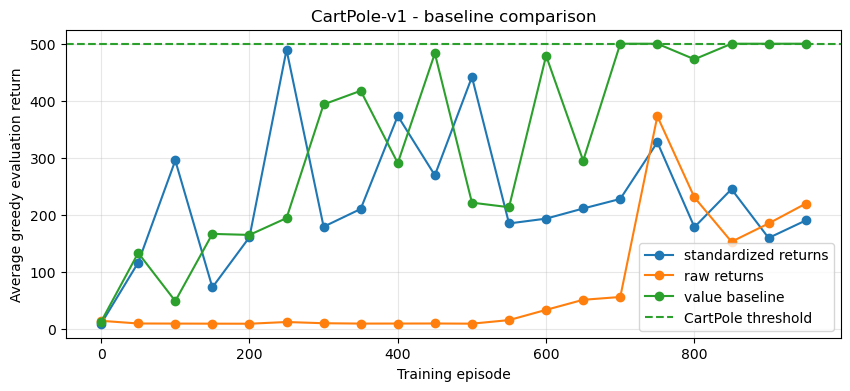

In [15]:
if RUN_VALUE_BASELINE_TRAINING:
    plt.figure(figsize=(10, 4))
    plt.plot(history_std["eval_episodes"], history_std["eval_avg_returns"], marker="o", label="return standardizzati")
    plt.plot(history_raw["eval_episodes"], history_raw["eval_avg_returns"], marker="o", label="return grezzi")
    plt.plot(history_v["eval_episodes"], history_v["eval_avg_returns"], marker="o", label="baseline di valore")
    plt.axhline(500, linestyle="--", color="tab:green", label="Soglia CartPole")
    plt.xlabel("Episodio di training")
    plt.ylabel("Return medio della valutazione greedy")
    plt.title("CartPole-v1 - confronto delle baseline")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Training non rieseguito: viene mostrato il confronto della run finale.")
    if DISPLAY_SAVED_RESULTS:
        display(Image(filename=PROJECT_ROOT / "figures" / "cartpole_value_baseline_comparison.png"))


In [16]:
if RUN_VALUE_BASELINE_TRAINING:
    def first_episode_reaching(history, threshold=500.0):
        for episode, avg_return in zip(history["eval_episodes"], history["eval_avg_returns"]):
            if avg_return >= threshold:
                return episode
        return None


    comparison = [
        {
            "method": "return standardizzati",
            "best_eval_return": max(history_std["eval_avg_returns"]),
            "final_eval_return": history_std["eval_avg_returns"][-1],
            "first_episode_reaching_500": first_episode_reaching(history_std),
        },
        {
            "method": "return grezzi",
            "best_eval_return": max(history_raw["eval_avg_returns"]),
            "final_eval_return": history_raw["eval_avg_returns"][-1],
            "first_episode_reaching_500": first_episode_reaching(history_raw),
        },
        {
            "method": "baseline di valore",
            "best_eval_return": max(history_v["eval_avg_returns"]),
            "final_eval_return": history_v["eval_avg_returns"][-1],
            "first_episode_reaching_500": first_episode_reaching(history_v),
        },
    ]
    comparison
else:
    comparison = pd.read_csv(PROJECT_ROOT / "results" / "method_summary.csv").query("environment == 'CartPole-v1'")
    display(comparison)


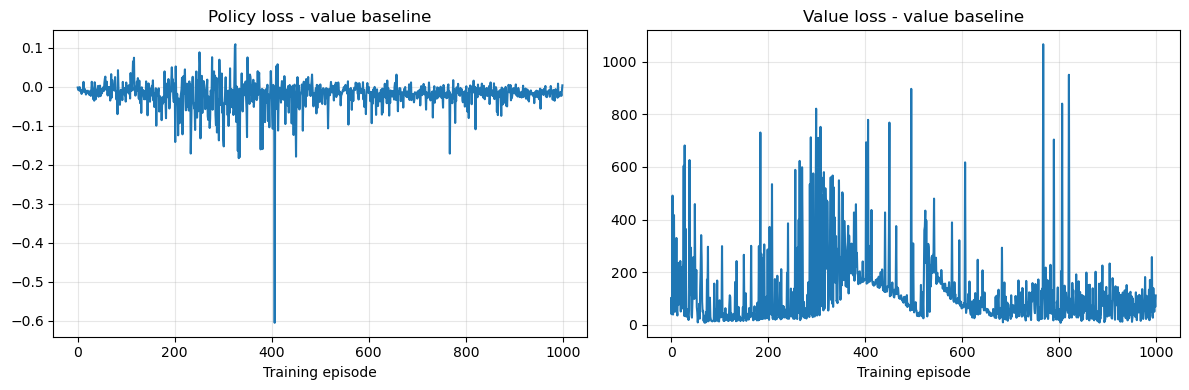

In [17]:
if RUN_VALUE_BASELINE_TRAINING:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_v["policy_losses"])
    plt.title("Loss della policy - baseline di valore")
    plt.xlabel("Episodio di training")
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history_v["value_losses"])
    plt.title("Loss del valore - baseline di valore")
    plt.xlabel("Episodio di training")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Loss preservate nell'output eseguito.")


## 5. Controllo visuale opzionale: cinque episodi CartPole

Il controllo usa `cartpole_reinforce_value_baseline.pt`, il checkpoint che ha ottenuto `500.00` nella valutazione finale a 20 episodi. Il risultato A2C `494.51` deriva invece da 100 episodi greedy e non è direttamente confrontabile.

I cinque rollout sono qualitativi. Il JSON versionato conserva seed, return, lunghezza, `terminated` e `truncated`; frame e animazioni HTML non vengono salvati. Il rendering è disattivato nella consegna.


In [ ]:
RUN_CARTPOLE_VISUALIZATION = False
CARTPOLE_VISUAL_CHECKPOINT = checkpoint_dir("cartpole_reinforce_value_baseline.pt", create=False)
CARTPOLE_VISUAL_RESULTS = PROJECT_ROOT / "results" / "cartpole_visual_episodes.json"

if RUN_CARTPOLE_VISUALIZATION:
    cartpole_visual_summary = run_cartpole_visual_episodes(
        checkpoint_path=CARTPOLE_VISUAL_CHECKPOINT,
        model_type="reinforce_policy",
        n_episodes=5,
        action_mode="greedy",
        seed_base=11_112,
        show_inline=True,
        summary_path=CARTPOLE_VISUAL_RESULTS,
    )
else:
    print("Rendering CartPole disattivato; viene mostrato il riepilogo salvato.")
    if CARTPOLE_VISUAL_RESULTS.is_file():
        cartpole_visual_summary = json.loads(CARTPOLE_VISUAL_RESULTS.read_text(encoding="utf-8"))
        print("Checkpoint:", cartpole_visual_summary["checkpoint"])
        print("Seed:", cartpole_visual_summary["episode_seeds"])
        for row in cartpole_visual_summary["episodes"]:
            print(
                f"episode={row['episode']} seed={row['seed']} return={row['return']:.0f} "
                f"length={row['length']} terminated={row['terminated']} "
                f"truncated={row['truncated']}"
            )
    else:
        cartpole_visual_summary = None
        print("Riepilogo non disponibile; attivare il flag con il checkpoint locale.")


episode=1 seed=805471 return=500 length=500 terminated=False truncated=True
Visual episode 1/5


episode=2 seed=233426 return=500 length=500 terminated=False truncated=True
Visual episode 2/5


episode=3 seed=748088 return=500 length=500 terminated=False truncated=True
Visual episode 3/5


episode=4 seed=994769 return=500 length=500 terminated=False truncated=True
Visual episode 4/5


episode=5 seed=795806 return=500 length=500 terminated=False truncated=True
Visual episode 5/5


## Conclusioni

Il confronto mostra: return standardizzati con miglior valutazione `489.35` e finale `190.20`; return grezzi con miglior valore `372.85` e finale `219.70`; baseline di valore con miglior valore e finale pari a `500.00`, soglia raggiunta per la prima volta all'episodio 700.

La baseline appresa è la configurazione più stabile della run. La policy loss rimane rumorosa, come atteso per i policy gradient, mentre la value loss descrive il problema ausiliario di regressione. Il confronto deriva da un solo seed e non quantifica la variabilità tra training indipendenti.


## Funzioni, classi e moduli locali richiamati

La tabella è ricavata dagli import, dagli utilizzi nelle celle e dalle definizioni effettive nei package locali.

| Funzione o classe | Tipo | File di definizione | Scopo | Input principali | Output principali | Sezione |
| ----------------- | ---- | ------------------- | ----- | ---------------- | ----------------- | ------- |
| `checkpoint_dir` | Funzione | `src/dla_lab3/paths.py` | Restituisce un percorso interno a `checkpoints`. | `create: bool`, `*parts` | Percorso interno alla cartella `checkpoints`. | 1. REINFORCE con return standardizzati; 2. Controllo con return grezzi; 3. Baseline di valore appresa; 5. Controllo visuale opzionale: cinque episodi CartPole |
| `evaluate_policy` | Funzione | `src/dla_lab3/policy_gradient.py` | Valuta una policy su più episodi. | `env`, `policy: PolicyNet`, `obs_scale: torch.Tensor`, `episodes: int`, `max_steps: int`, `mode: ActionMode`, `temperature: float`, `seed_start: int \| None` | Dizionario con media, deviazione, minimo e massimo del return, lunghezza media e array grezzi. | Valutazione periodica interna |
| `make_env` | Funzione | `src/dla_lab3/envs.py` | Crea un ambiente Gymnasium e ne imposta il seed. | `env_id: str`, `seed: int \| None`, `render_mode: str \| None`, `**kwargs` | Ambiente Gymnasium pronto per l'uso. | 1. REINFORCE con return standardizzati; 2. Controllo con return grezzi; 3. Baseline di valore appresa |
| `observation_scale` | Funzione | `src/dla_lab3/envs.py` | Restituisce la scala delle osservazioni per gli ambienti supportati. | `env_id: str` | Tensore float con un valore per dimensione dell'osservazione. | 1. REINFORCE con return standardizzati |
| `policy_from_env` | Funzione | `src/dla_lab3/policy_gradient.py` | Costruisce una rete di policy da un ambiente Gymnasium. | `env`, `hidden_size: int` | `PolicyNet` configurata per l'ambiente. | 1. REINFORCE con return standardizzati; 2. Controllo con return grezzi; 3. Baseline di valore appresa |
| `PolicyNet` | Classe | `src/dla_lab3/policy_gradient.py` | Policy MLP stocastica per osservazioni continue e azioni discrete. | `obs_dim: int`, `n_actions: int`, `hidden_size: int` | Istanza configurata della classe. | Creazione delle policy |
| `reinforce` | Funzione | `src/dla_lab3/policy_gradient.py` | Addestra una policy con REINFORCE standard. | `policy: PolicyNet`, `env`, `eval_env`, `obs_scale: torch.Tensor`, `config: ReinforceConfig` | Dizionario con return per episodio, loss, metriche di valutazione e informazioni sul checkpoint migliore. | 1. REINFORCE con return standardizzati; 2. Controllo con return grezzi |
| `reinforce_with_value_baseline` | Funzione | `src/dla_lab3/policy_gradient.py` | Addestra REINFORCE con una baseline di valore appresa. | `policy: PolicyNet`, `value_net: ValueNet`, `env`, `eval_env`, `obs_scale: torch.Tensor`, `config: ReinforceConfig` | Dizionario con curve di training, metriche di valutazione e informazioni sui checkpoint. | 3. Baseline di valore appresa |
| `ReinforceConfig` | Classe | `src/dla_lab3/policy_gradient.py` | Configurazione di training per gli esperimenti REINFORCE. | `gamma`, `lr_policy`, `lr_value`, `num_episodes`, `max_episode_steps`, `eval_every`, `eval_episodes`, `baseline_mode` | Istanza configurata della classe. | 1. REINFORCE con return standardizzati; 2. Controllo con return grezzi; 3. Baseline di valore appresa |
| `run_cartpole_visual_episodes` | Funzione | `src/dla_lab3/visualization.py` | Esegue episodi visuali CartPole riproducibili senza aggiornare il modello. | `checkpoint_path: str \| Path`, `model_type: str`, `n_episodes: int`, `action_mode: str`, `seed_base: int`, `show_inline: bool`, `summary_path: str \| Path \| None`, `hidden_size: int` | Dizionario con checkpoint, modalita', seed e statistiche per episodio. I frame non vengono inclusi nel valore restituito o nel JSON. | 5. Controllo visuale opzionale: cinque episodi CartPole |
| `run_episode` | Funzione | `src/dla_lab3/policy_gradient.py` | Esegue un episodio completo. | `env`, `policy: PolicyNet`, `obs_scale: torch.Tensor`, `max_steps: int`, `mode: ActionMode`, `temperature: float`, `seed: int \| None` | Dataclass `Episode` con tensori del rollout e statistiche di sintesi. | Interno a training e valutazione |
| `set_seed` | Funzione | `src/dla_lab3/seed.py` | Imposta i seed di Python, NumPy e PyTorch. | `seed: int` | Nessuno. Modifica lo stato globale dei generatori casuali e, se disponibile, quello di tutti i device CUDA. | 1. REINFORCE con return standardizzati; 2. Controllo con return grezzi; 3. Baseline di valore appresa |
| `value_from_env` | Funzione | `src/dla_lab3/policy_gradient.py` | Costruisce una rete di valore da un ambiente Gymnasium. | `env`, `hidden_size: int` | `ValueNet` configurata per l'ambiente. | 3. Baseline di valore appresa |
| `ValueNet` | Classe | `src/dla_lab3/policy_gradient.py` | Rete MLP per la baseline del valore di stato. | `obs_dim: int`, `hidden_size: int` | Istanza configurata della classe. | Creazione della baseline di valore |
